<a href="https://colab.research.google.com/github/LoraShima/Computer_Vision_Final_Project/blob/main/ComputerVisionProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
from PIL import Image
import hashlib
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, cohen_kappa_score, mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
dataset_folder = "/content/drive/MyDrive/Dataset"

Step 1: Dataset Cleaning / Preparation


1.   Checking for corrupted images or if there are different sizes
2.   Checking if there are duplicates



In [9]:
sizes = set()
errors = []

for split_name in os.listdir(dataset_folder):
    split_path = os.path.join(dataset_folder, split_name)
    if not os.path.isdir(split_path):
        continue

    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)
        if not os.path.isdir(class_path):
            continue

        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                img = Image.open(img_path)
                img.verify()
                sizes.add(img.size)
            except:
                errors.append(img_path)

if len(sizes) == 1:
    print(f"All images have the same size: {sizes.pop()}")
else:
    print(f"Images have different sizes. Unique sizes found: {sizes}")

if errors:
    print(f"\nWarning: Could not open {len(errors)} files:")
    for e in errors:
        print(f" - {e}")


All images have the same size: (256, 256)


In [ ]:
hashes = {}
removed = []

def get_file_hash(file_path):
    hasher = hashlib.md5()
    with open(file_path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            hasher.update(chunk)
    return hasher.hexdigest()

for split_name in os.listdir(dataset_folder):
    split_path = os.path.join(dataset_folder, split_name)
    if not os.path.isdir(split_path):
        continue

    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)
        if not os.path.isdir(class_path):
            continue

        for filename in os.listdir(class_path):
            if filename.startswith("."):
                continue

            file_path = os.path.join(class_path, filename)
            if not os.path.isfile(file_path):
                continue

            try:
                file_hash = get_file_hash(file_path)
            except Exception as e:
                print(f"Error reading {file_path}: {e}")
                continue

            if file_hash in hashes:
                first_path = hashes[file_hash]

                size1 = os.path.getsize(first_path)
                size2 = os.path.getsize(file_path)

                os.remove(file_path)
                removed.append(file_path)

                print(
                    "Removed duplicate:\n"
                    f"  Deleted: {file_path} ({size2} bytes)\n"
                    f"  Kept:    {first_path} ({size1} bytes)\n"
                )
            else:
                hashes[file_hash] = file_path

print(f"Total duplicates removed: {len(removed)}")


Total duplicates removed: 0


Step 2: Preprocess/Augmentation

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

Dataset

In [5]:
train_dir = os.path.join(dataset_folder, "train")
val_dir   = os.path.join(dataset_folder, "validation")
test_dir  = os.path.join(dataset_folder, "test")

def count_images(folder_path):
    total = 0
    for class_name in os.listdir(folder_path):
        class_path = os.path.join(folder_path, class_name)
        if os.path.isdir(class_path):
            total += len(os.listdir(class_path))
    return total

print(f"Nr of images in train: {count_images(train_dir)}")
print(f"Nr of images in validation: {count_images(val_dir)}")
print(f"Nr of images in test: {count_images(test_dir)}")

train_dataset = ImageFolder(train_dir, transform=train_transform)
val_dataset   = ImageFolder(val_dir, transform=val_test_transform)
test_dataset  = ImageFolder(test_dir, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

num_classes = len(train_dataset.classes)
print("Classes:", train_dataset.classes)


Nr of images in train: 5589
Nr of images in validation: 800
Nr of images in test: 1609
Classes: ['Bridge', 'Commercial', 'Industrial', 'Intersection', 'Landmark', 'Park', 'Parking', 'Playground', 'Residential', 'Stadium']


In [6]:
class ModelTrainer:
    def __init__(self, model, train_dl, val_dl, test_dl, criterion, optimizer, device):
        self.model = model
        self.train_dl = train_dl
        self.val_dl = val_dl
        self.test_dl = test_dl
        self.criterion = criterion
        self.optimizer = optimizer
        self.device = device

    def train(self, num_epochs):
        for epoch in range(num_epochs):

            self.model.train()
            train_loss = 0.0
            y_true_train, y_pred_train = [], []

            for inputs, labels in self.train_dl:
                inputs, labels = inputs.to(self.device), labels.to(self.device)

                self.optimizer.zero_grad()
                outputs = self.model(inputs)
                loss = self.criterion(outputs, labels)
                loss.backward()
                self.optimizer.step()

                train_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                y_true_train.extend(labels.cpu().numpy())
                y_pred_train.extend(preds.cpu().numpy())

            train_loss /= len(self.train_dl.dataset)
            train_acc = accuracy_score(y_true_train, y_pred_train)

            self.model.eval()
            val_loss = 0.0
            y_true_val, y_pred_val = [], []

            with torch.no_grad():
                for inputs, labels in self.val_dl:
                    inputs, labels = inputs.to(self.device), labels.to(self.device)
                    outputs = self.model(inputs)
                    loss = self.criterion(outputs, labels)

                    val_loss += loss.item() * inputs.size(0)
                    _, preds = torch.max(outputs, 1)

                    y_true_val.extend(labels.cpu().numpy())
                    y_pred_val.extend(preds.cpu().numpy())

            val_loss /= len(self.val_dl.dataset)
            val_acc = accuracy_score(y_true_val, y_pred_val)

            print(
                f"Epoch [{epoch+1}/{num_epochs}] | "
                f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
                f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
            )

    def evaluate(self):
        self.model.eval()
        y_true, y_pred = [], []

        with torch.no_grad():
            for inputs, labels in self.test_dl:
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                outputs = self.model(inputs)
                _, preds = torch.max(outputs, 1)

                y_true.extend(labels.cpu().numpy())
                y_pred.extend(preds.cpu().numpy())

        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, average='weighted')
        rec = recall_score(y_true, y_pred, average='weighted')
        f1 = f1_score(y_true, y_pred, average='weighted')
        kappa = cohen_kappa_score(y_true, y_pred)
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        rae = mae / np.mean(np.abs(y_true - np.mean(y_true)))
        rrse = rmse / np.std(y_true)

        print("\n      TEST EVALUATION       ")
        print(f"Accuracy: {acc:.4f}")
        print(f"Precision: {prec:.4f}")
        print(f"Recall: {rec:.4f}")
        print(f"F1-score: {f1:.4f}")
        print(f"Correctly Classified Instances: {acc*100:.2f}%")
        print(f"Incorrectly Classified Instances: {(1-acc)*100:.2f}%")
        print(f"Kappa Statistic: {kappa:.4f}")
        print(f"Mean Absolute Error: {mae:.4f}")
        print(f"Root Mean Squared Error: {rmse:.4f}")
        print(f"Relative Absolute Error: {rae:.4f}")
        print(f"Root Relative Squared Error: {rrse:.4f}")
        print("\nConfusion Matrix:")
        cm = confusion_matrix(y_true, y_pred)
        class_names = train_dataset.classes

        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu", xticklabels=class_names, yticklabels=class_names)
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title("Confusion Matrix")
        plt.show()


We have written a ModelTrainer class that serves as a manager for the entire lifecycle of the neural network, handling everything from initial configuration to training and final testing. In the initialization step, it bundles all necessary components including the model, the data loaders for training, validation, and testing, the loss function for measuring errors, the optimizer for updating weights, and the hardware device for processing. When the training method is called, the class enters a loop that repeats for a set number of epochs. During each epoch, the model first enters a learning mode where it processes training images in batches, clears previous gradients, makes predictions, calculates the loss, and uses backpropagation to adjust its internal parameters. Simultaneously, it tracks the running loss and accuracy to monitor performance.
Following the training phase of each epoch, the class switches the model to evaluation mode to conduct a validation check. This part of the process uses a separate set of data to provide an unbiased look at how well the model is generalizing rather than just memorizing training patterns. By using the torch.no_grad context, the system saves memory and time because it does not need to calculate gradients during this phase. After all training epochs are complete, the evaluation method is triggered to conduct a final exam on the test dataset.
This method generates a comprehensive suite of metrics to provide a detailed picture of the model's reliability across all ten classes.
1. *Accuracy* measures the overall percentage of images that the model correctly identified out of the total dataset.
2. *Precision* indicates the model's ability to avoid false positives, showing how many of the images predicted as a specific class actually belonged to it.
3. *Recall* calculates the model's ability to find all relevant instances, measuring how many images of a specific class were correctly captured out of all available images for that category.
4. *F1-score* provides a single balance between precision and recall, which is especially useful for ensuring the model performs well even in difficult-to-distinguish categories.
5. *Kappa Statistic (Cohen’s Kappa)* measures how much better your model is performing compared to a model that simply makes random guesses, taking into account the possibility of agreement by chance.
6. *Mean Absolute Error (MAE)* calculates the average ‘distance’ between the predicted class index and the actual class index, giving a simple idea of how far off the wrong guesses usually are.
7. *Root Mean Squared Error (RMSE)* is similar to MAE but gives a higher penalty to larger mistakes, making it useful for seeing if the model is making very ‘distant’ errors (like confusing a Bridge for a Stadium).
8. *Relative Absolute Error (RAE)* compares the model's total error to the error of a very simple baseline that only predicts the average, showing how much more effective your CNN is than a basic guess.
9. *Root Relative Squared Error (RRSE)* scales the RMSE by the variation in the actual data, providing a percentage-like score that indicates how well the model captures the overall patterns in the 10 urban classes.
10. *Confusion Matrix* acts as a visual heatmap that reveals exactly which urban categories—such as Commercial and Industrial—the model is confusing, allowing for a deep analysis of classification errors.


In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


**VGG19**
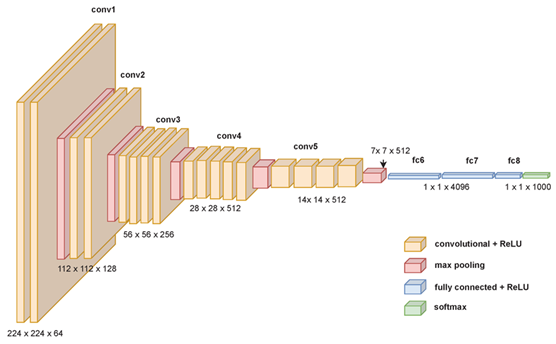

VGG19 is a deep convolutional neural network designed specifically for high-performance image classification, consisting of 19 layers with learnable weights that include 16 convolutional layers and 3 fully connected layers. The architecture works by passing an input image through a series of ‘visual filters’ where the early layers identify simple features like edges and colors, while the middle layers begin to recognize more complex patterns like textures or specific shapes. It utilizes small 3x3 filters across all its convolutional layers to capture fine details, followed by pooling layers that reduce the image size while retaining the most important information. Once the image is transformed into a compressed feature map, it passes through the final fully connected layers that act as a classifier to determine which of the ten urban categories the image belongs to.
At the very end of this architecture, the model uses the Softmax activation function to produce the final output. In a multi-class project like this, Softmax takes the raw numerical scores from the last layer and converts them into probabilities that sum up to 100%. This allows the model to assign a confidence level to each class, such as concluding there is an 85% probability an image is a ‘Stadium’ and a 10% probability it is a ‘Playground’. By turning these scores into a clear probability distribution, Softmax enables the model to make a definitive ‘best guess’ while showing us how certain it is about the classification.


Epoch [1/15] | Train Loss: 2.1671, Train Acc: 0.1594 | Val Loss: 1.7876, Val Acc: 0.2350
Epoch [2/15] | Train Loss: 1.6613, Train Acc: 0.3630 | Val Loss: 1.6172, Val Acc: 0.4288
Epoch [3/15] | Train Loss: 1.4492, Train Acc: 0.4659 | Val Loss: 1.3936, Val Acc: 0.4900
Epoch [4/15] | Train Loss: 1.3329, Train Acc: 0.5187 | Val Loss: 1.2524, Val Acc: 0.5475
Epoch [5/15] | Train Loss: 1.2373, Train Acc: 0.5570 | Val Loss: 1.1496, Val Acc: 0.5813
Epoch [6/15] | Train Loss: 1.1461, Train Acc: 0.5996 | Val Loss: 1.1339, Val Acc: 0.6075
Epoch [7/15] | Train Loss: 1.0360, Train Acc: 0.6348 | Val Loss: 1.0842, Val Acc: 0.6412
Epoch [8/15] | Train Loss: 0.9171, Train Acc: 0.6828 | Val Loss: 0.9923, Val Acc: 0.6512
Epoch [9/15] | Train Loss: 0.8324, Train Acc: 0.7094 | Val Loss: 0.8381, Val Acc: 0.7100
Epoch [10/15] | Train Loss: 0.7582, Train Acc: 0.7343 | Val Loss: 0.8228, Val Acc: 0.7100
Epoch [11/15] | Train Loss: 0.6790, Train Acc: 0.7676 | Val Loss: 0.7599, Val Acc: 0.7338
Epoch [12/15] | Tra

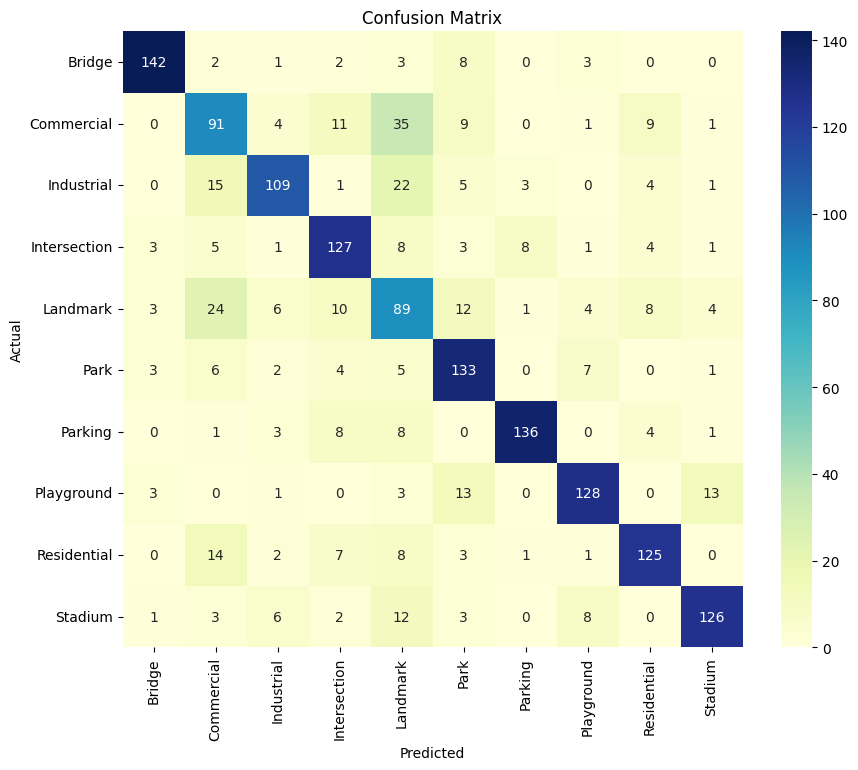

In [ ]:
model_vgg_false = models.vgg19(pretrained=False)
model_vgg_false.classifier[6] = nn.Linear(model_vgg_false.classifier[6].in_features, num_classes)
model_vgg_false = model_vgg_false.to(device)

criterion_vgg = nn.CrossEntropyLoss()
optimizer_vgg = optim.Adam(model_vgg_false.parameters(), lr=0.0001)

trainer = ModelTrainer(model_vgg_false, train_loader, val_loader, test_loader, criterion_vgg, optimizer_vgg, device)

trainer.train(num_epochs=15)
trainer.evaluate()

**Optimized VGG19**

Epoch [1/15] | Train Loss: 0.9349, Train Acc: 0.6851 | Val Loss: 0.4093, Val Acc: 0.8600
Epoch [2/15] | Train Loss: 0.4472, Train Acc: 0.8572 | Val Loss: 0.2387, Val Acc: 0.9150
Epoch [3/15] | Train Loss: 0.3062, Train Acc: 0.9009 | Val Loss: 0.2864, Val Acc: 0.9175
Epoch [4/15] | Train Loss: 0.2674, Train Acc: 0.9179 | Val Loss: 0.1700, Val Acc: 0.9500
Epoch [5/15] | Train Loss: 0.2246, Train Acc: 0.9270 | Val Loss: 0.2779, Val Acc: 0.9100
Epoch [6/15] | Train Loss: 0.1828, Train Acc: 0.9431 | Val Loss: 0.2055, Val Acc: 0.9325
Epoch [7/15] | Train Loss: 0.1754, Train Acc: 0.9449 | Val Loss: 0.2480, Val Acc: 0.9337
Epoch [8/15] | Train Loss: 0.1664, Train Acc: 0.9488 | Val Loss: 0.2299, Val Acc: 0.9325
Epoch [9/15] | Train Loss: 0.1740, Train Acc: 0.9494 | Val Loss: 0.3378, Val Acc: 0.9150
Epoch [10/15] | Train Loss: 0.1421, Train Acc: 0.9562 | Val Loss: 0.1797, Val Acc: 0.9500
Epoch [11/15] | Train Loss: 0.0860, Train Acc: 0.9723 | Val Loss: 0.1793, Val Acc: 0.9487
Epoch [12/15] | Tra

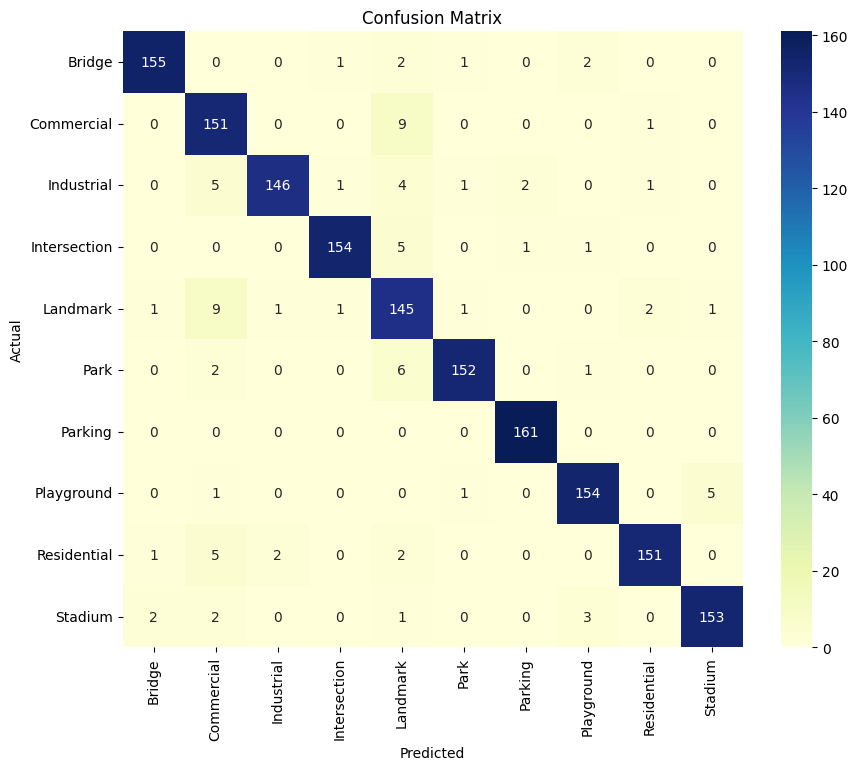

In [ ]:
model = models.vgg19(pretrained=True)
model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
model = model.to(device)

criterion_vgg = nn.CrossEntropyLoss()
optimizer_vgg = optim.Adam(model.parameters(), lr=0.0001)

trainer = ModelTrainer(model, train_loader, val_loader, test_loader, criterion_vgg, optimizer_vgg, device)

trainer.train(num_epochs=15)
trainer.evaluate()

**ResNet101**
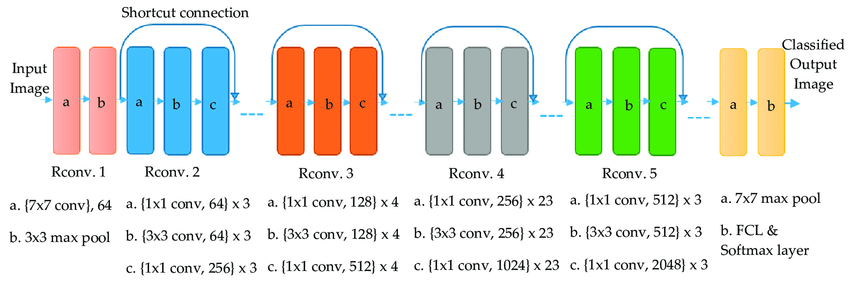

ResNet101 is a very deep convolutional neural network designed for high-performance image classification, consisting of 101 layers with learnable weights. Unlike traditional deep networks, ResNet101 introduces a unique mechanism called residual or skip connections, which allows the network to pass information from earlier layers directly to later layers. This approach helps the network maintain important features as it becomes extremely deep, preventing problems like vanishing gradients that can make training very deep networks difficult. When an input image is fed into ResNet101, it first passes through an initial convolutional layer and pooling layer that begin to detect basic visual features such as edges, textures, and colors. The image then travels through a series of residual blocks, where each block applies convolutions, normalizations, and non-linearities while adding the original input of the block to its output. This process allows the network to learn increasingly complex features, from mid-level patterns like shapes and object parts to high-level representations that capture entire structures relevant for classifying the image. Finally, after the feature extraction layers, the network performs global average pooling to reduce the feature map into a single vector, which is passed to a fully connected layer acting as a classifier for your ten urban categories. At the very end, ResNet101 uses the Softmax activation function to produce the final output

In [ ]:
model_resnet_false = models.resnet101(pretrained=False)

model_resnet_false.fc = nn.Linear(model_resnet_false.fc.in_features, num_classes)
model_resnet_false = model_resnet_false.to(device)
criterion_resnet = nn.CrossEntropyLoss()
optimizer_resnet = optim.Adam(model_resnet_false.parameters(), lr=0.0001)

trainer = ModelTrainer(model_resnet_false, train_loader, val_loader, test_loader, criterion_resnet, optimizer_resnet, device)

trainer.train(num_epochs=15)
trainer.evaluate()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Epoch [1/15] | Train Loss: 1.9579, Train Acc: 0.2963 | Val Loss: 1.7293, Val Acc: 0.3800
Epoch [2/15] | Train Loss: 1.6225, Train Acc: 0.4282 | Val Loss: 1.6026, Val Acc: 0.4263


**Optimized ResNet101**

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /root/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth


100%|██████████| 171M/171M [00:00<00:00, 193MB/s]


Epoch [1/15] | Train Loss: 0.5508, Train Acc: 0.8189 | Val Loss: 0.1677, Val Acc: 0.9463
Epoch [2/15] | Train Loss: 0.2534, Train Acc: 0.9200 | Val Loss: 0.1739, Val Acc: 0.9425
Epoch [3/15] | Train Loss: 0.1730, Train Acc: 0.9449 | Val Loss: 0.0930, Val Acc: 0.9725
Epoch [4/15] | Train Loss: 0.1245, Train Acc: 0.9588 | Val Loss: 0.1485, Val Acc: 0.9587
Epoch [5/15] | Train Loss: 0.1218, Train Acc: 0.9630 | Val Loss: 0.1321, Val Acc: 0.9525
Epoch [6/15] | Train Loss: 0.0944, Train Acc: 0.9683 | Val Loss: 0.1360, Val Acc: 0.9637
Epoch [7/15] | Train Loss: 0.1026, Train Acc: 0.9685 | Val Loss: 0.1157, Val Acc: 0.9650
Epoch [8/15] | Train Loss: 0.0924, Train Acc: 0.9699 | Val Loss: 0.1486, Val Acc: 0.9550
Epoch [9/15] | Train Loss: 0.0542, Train Acc: 0.9823 | Val Loss: 0.1439, Val Acc: 0.9625
Epoch [10/15] | Train Loss: 0.0647, Train Acc: 0.9794 | Val Loss: 0.1588, Val Acc: 0.9550
Epoch [11/15] | Train Loss: 0.0624, Train Acc: 0.9787 | Val Loss: 0.1361, Val Acc: 0.9600
Epoch [12/15] | Tra

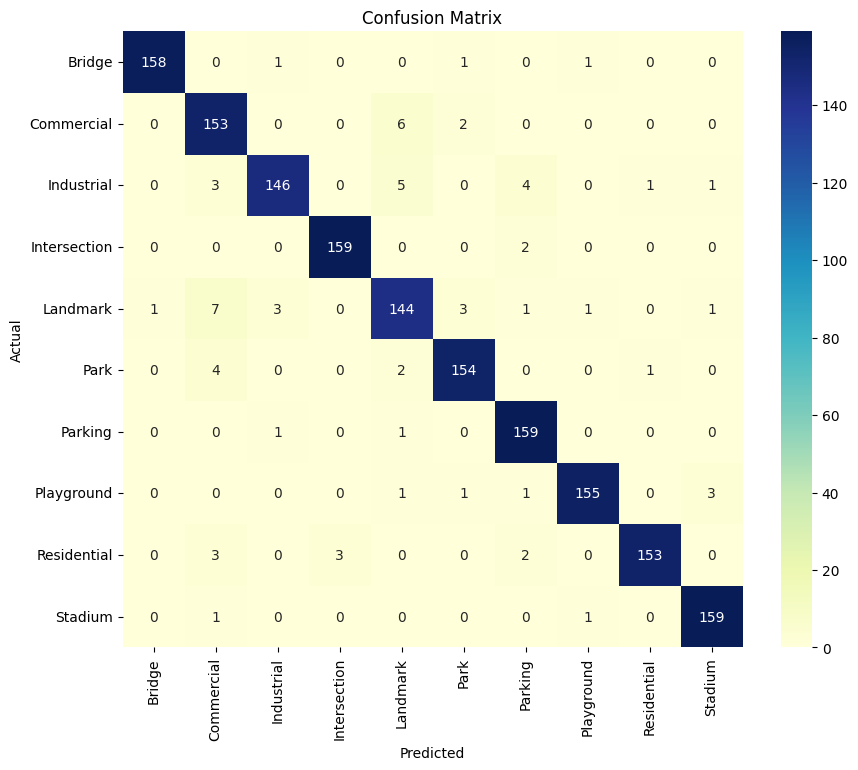

In [ ]:
model_resnet = models.resnet101(pretrained=True)

model_resnet.fc = nn.Linear(model_resnet.fc.in_features, num_classes)
model_resnet = model_resnet.to(device)
criterion_resnet = nn.CrossEntropyLoss()
optimizer_resnet = optim.Adam(model_resnet.parameters(), lr=0.0001)

trainer = ModelTrainer(model_resnet, train_loader, val_loader, test_loader, criterion_resnet, optimizer_resnet, device)

trainer.train(num_epochs=15)
trainer.evaluate()

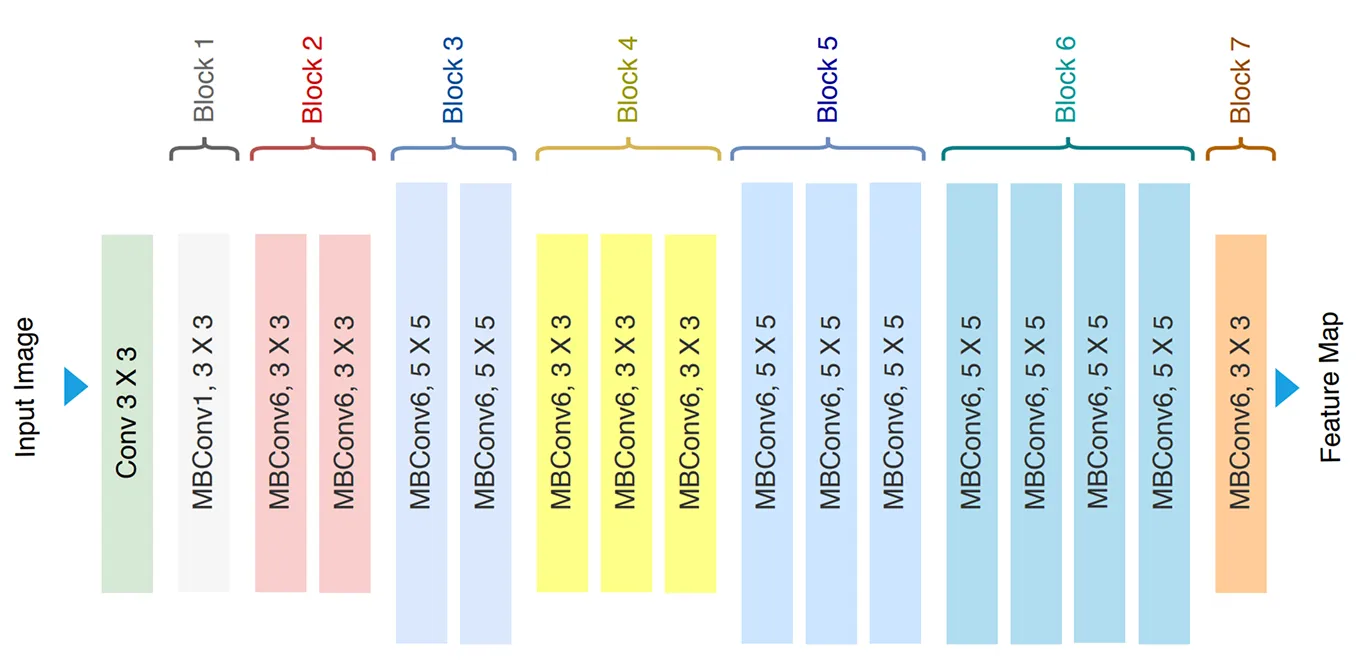
**EfficientNet-B0**

EfficientNet-B0 is a modern convolutional neural network architecture designed to achieve high classification accuracy while maintaining computational efficiency. Unlike traditional CNNs that increase network depth, width, or input resolution independently, EfficientNet introduces a compound scaling strategy that balances all three dimensions simultaneously. This allows the model to extract richer visual features while using significantly fewer parameters than many deeper architectures. As illustrated in the architecture, the input image first passes through an initial convolutional layer that captures low-level features such as edges, colors, and textures. The network then processes the image through a sequence of Mobile Inverted Bottleneck Convolution (MBConv) blocks organized into seven stages. These MBConv blocks combine depthwise separable convolutions, expansion layers, and squeeze-and-excitation mechanisms to efficiently learn increasingly complex representations while reducing computational cost. As the image progresses through the successive blocks, the network extracts higher-level semantic information, enabling it to recognize complex urban structures such as bridges, stadiums, residential areas, and intersections. After the final MBConv stage, the extracted feature maps are aggregated through global average pooling and passed to a fully connected classification layer. Finally, a Softmax activation function produces the probability distribution across the ten urban scene categories, assigning the image to the class with the highest probability.


Epoch [1/15] | Train Loss: 1.9928, Train Acc: 0.2594 | Val Loss: 1.5665, Val Acc: 0.4437
Epoch [2/15] | Train Loss: 1.6271, Train Acc: 0.4285 | Val Loss: 1.2891, Val Acc: 0.5475
Epoch [3/15] | Train Loss: 1.3832, Train Acc: 0.5115 | Val Loss: 1.1436, Val Acc: 0.5863
Epoch [4/15] | Train Loss: 1.2461, Train Acc: 0.5618 | Val Loss: 1.0537, Val Acc: 0.6200
Epoch [5/15] | Train Loss: 1.1282, Train Acc: 0.6185 | Val Loss: 0.8875, Val Acc: 0.6825
Epoch [6/15] | Train Loss: 1.0467, Train Acc: 0.6375 | Val Loss: 0.8596, Val Acc: 0.6863
Epoch [7/15] | Train Loss: 0.9790, Train Acc: 0.6658 | Val Loss: 0.8512, Val Acc: 0.7037
Epoch [8/15] | Train Loss: 0.8962, Train Acc: 0.6953 | Val Loss: 0.7712, Val Acc: 0.7362
Epoch [9/15] | Train Loss: 0.8223, Train Acc: 0.7143 | Val Loss: 0.7651, Val Acc: 0.7325
Epoch [10/15] | Train Loss: 0.7619, Train Acc: 0.7366 | Val Loss: 0.7260, Val Acc: 0.7312
Epoch [11/15] | Train Loss: 0.6905, Train Acc: 0.7672 | Val Loss: 0.6659, Val Acc: 0.7638
Epoch [12/15] | Tra

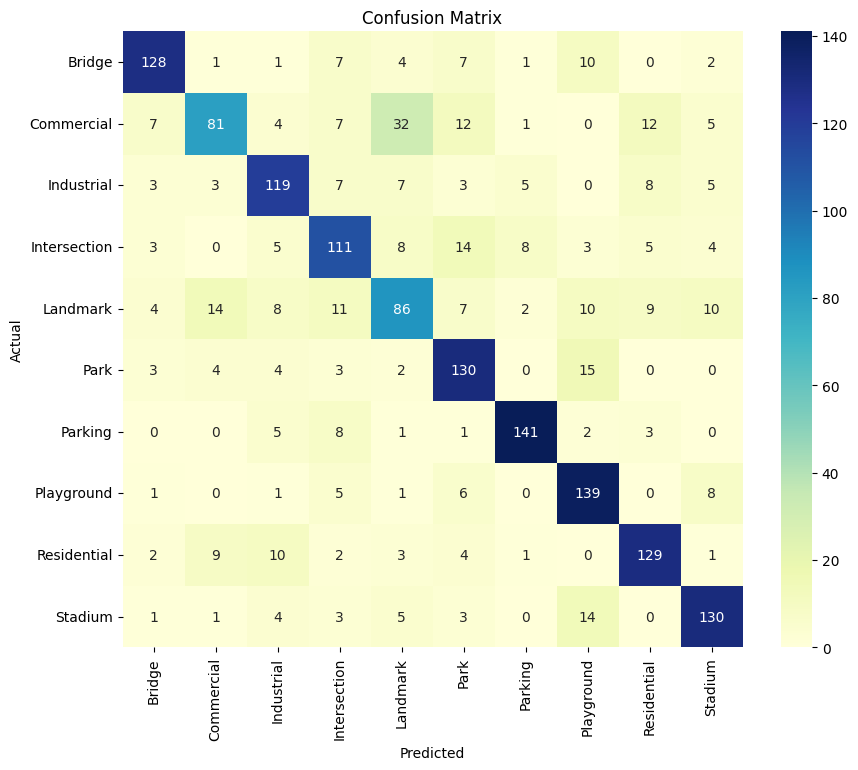

In [ ]:
model_effnet_false = models.efficientnet_b0(pretrained=False)

model_effnet_false.classifier[1] = nn.Linear(
    model_effnet_false.classifier[1].in_features,
    num_classes
)

model_effnet_false = model_effnet_false.to(device)

criterion_effnet = nn.CrossEntropyLoss()
optimizer_effnet = optim.Adam(model_effnet_false.parameters(), lr=0.0001)

trainer = ModelTrainer( model_effnet_false,train_loader,val_loader,test_loader,criterion_effnet,optimizer_effnet,device)

trainer.train(num_epochs=15)
trainer.evaluate()

**Optimized EfficientNet-B0**

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 95.6MB/s]


Epoch [1/15] | Train Loss: 0.9227, Train Acc: 0.7515 | Val Loss: 0.1550, Val Acc: 0.9575
Epoch [2/15] | Train Loss: 0.2643, Train Acc: 0.9198 | Val Loss: 0.1192, Val Acc: 0.9663
Epoch [3/15] | Train Loss: 0.1563, Train Acc: 0.9537 | Val Loss: 0.0890, Val Acc: 0.9712
Epoch [4/15] | Train Loss: 0.1073, Train Acc: 0.9698 | Val Loss: 0.0835, Val Acc: 0.9712
Epoch [5/15] | Train Loss: 0.0869, Train Acc: 0.9737 | Val Loss: 0.0784, Val Acc: 0.9775
Epoch [6/15] | Train Loss: 0.0630, Train Acc: 0.9805 | Val Loss: 0.0883, Val Acc: 0.9775
Epoch [7/15] | Train Loss: 0.0485, Train Acc: 0.9875 | Val Loss: 0.0689, Val Acc: 0.9825
Epoch [8/15] | Train Loss: 0.0446, Train Acc: 0.9864 | Val Loss: 0.0704, Val Acc: 0.9812
Epoch [9/15] | Train Loss: 0.0392, Train Acc: 0.9884 | Val Loss: 0.0656, Val Acc: 0.9838
Epoch [10/15] | Train Loss: 0.0390, Train Acc: 0.9882 | Val Loss: 0.0671, Val Acc: 0.9838
Epoch [11/15] | Train Loss: 0.0371, Train Acc: 0.9884 | Val Loss: 0.0920, Val Acc: 0.9712
Epoch [12/15] | Tra

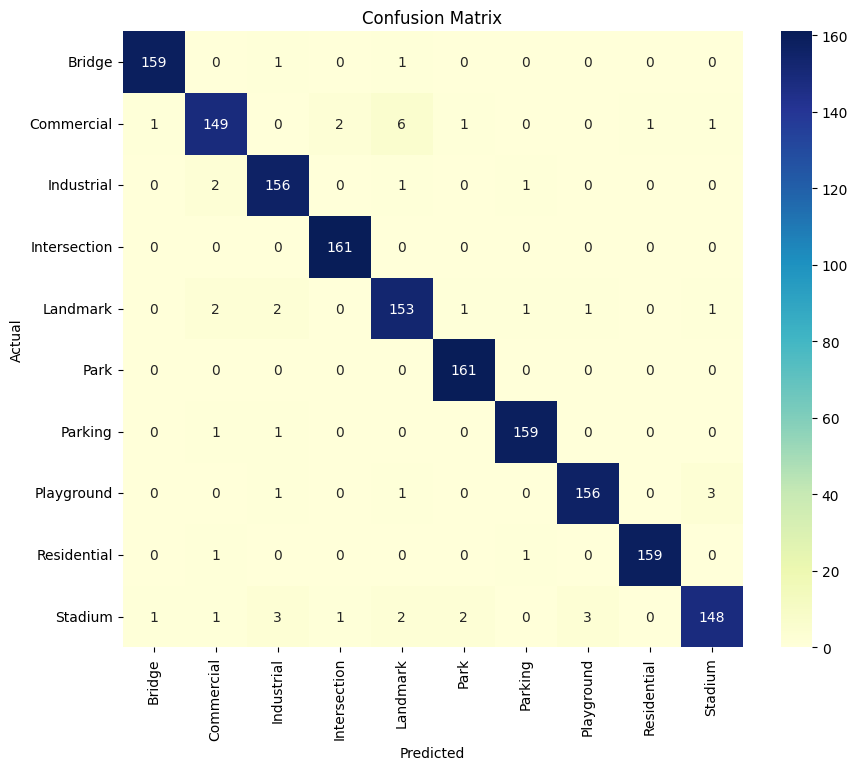

In [ ]:
model_effnet_false = models.efficientnet_b0(pretrained=True)

model_effnet_false.classifier[1] = nn.Linear(
    model_effnet_false.classifier[1].in_features,
    num_classes
)

model_effnet_false = model_effnet_false.to(device)

criterion_effnet = nn.CrossEntropyLoss()
optimizer_effnet = optim.Adam(model_effnet_false.parameters(), lr=0.0001)

trainer = ModelTrainer( model_effnet_false,train_loader,val_loader,test_loader,criterion_effnet,optimizer_effnet,device)

trainer.train(num_epochs=15)
trainer.evaluate()

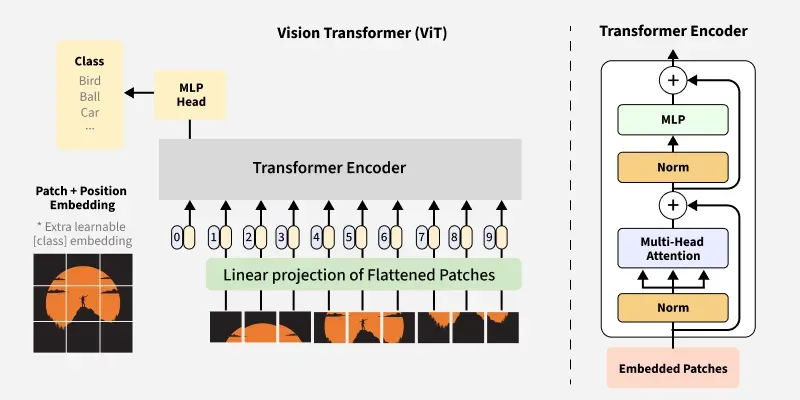

**Vision Transformer (ViT)**

The Vision Transformer (ViT) is a transformer-based architecture that adapts the principles of natural language processing transformers to image classification tasks. Unlike convolutional neural networks, which process images using convolutional filters, ViT divides the input image into a sequence of fixed-size patches and treats each patch as a token, similar to words in a sentence. As shown in the architecture, the image is first partitioned into multiple patches, which are then flattened and transformed into vector representations through a linear projection process. Positional embeddings are added to these patch embeddings to preserve the spatial relationships between different image regions. A special classification token is also included and serves as a global representation of the image throughout the network. The sequence of embedded patches is then processed by a stack of Transformer Encoder layers. Each encoder consists of Layer Normalization, Multi-Head Self-Attention, and Multi-Layer Perceptron (MLP) components connected through residual connections. The self-attention mechanism allows every image patch to directly interact with all other patches, enabling the model to capture long-range dependencies and global contextual information. This capability is particularly useful for scene classification tasks, where understanding the relationships between distant regions of an image can be crucial. After passing through the transformer encoders, the final representation of the classification token is fed into an MLP classification head. The Softmax activation function is then applied to generate probabilities for the ten urban scene categories and determine the final prediction.

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Epoch [1/15] | Train Loss: 1.9558, Train Acc: 0.3008 | Val Loss: 1.5243, Val Acc: 0.4525
Epoch [2/15] | Train Loss: 1.4086, Train Acc: 0.5055 | Val Loss: 1.1924, Val Acc: 0.5887
Epoch [3/15] | Train Loss: 1.2117, Train Acc: 0.5783 | Val Loss: 1.1263, Val Acc: 0.6025
Epoch [4/15] | Train Loss: 1.1197, Train Acc: 0.6180 | Val Loss: 1.0945, Val Acc: 0.6050
Epoch [5/15] | Train Loss: 1.0198, Train Acc: 0.6522 | Val Loss: 1.0830, Val Acc: 0.6350
Epoch [6/15] | Train Loss: 0.9659, Train Acc: 0.6704 | Val Loss: 1.0465, Val Acc: 0.6312
Epoch [7/15] | Train Loss: 0.8887, Train Acc: 0.6935 | Val Loss: 1.0571, Val Acc: 0.6388
Epoch [8/15] | Train Loss: 0.8309, Train Acc: 0.7094 | Val Loss: 0.8792, Val Acc: 0.7000
Epoch [9/15] | Train Loss: 0.7962, Train Acc: 0.7230 | Val Loss: 0.9676, Val Acc: 0.6750
Epoch [10/15] | Train Loss: 0.7485, Train Acc: 0.7400 | Val Loss: 1.0017, Val Acc: 0.6500
Epoch [11/15] | Train Loss: 0.7210, Train Acc: 0.7508 | Val Loss: 0.9169, Val Acc: 0.6975
Epoch [12/15] | Tra

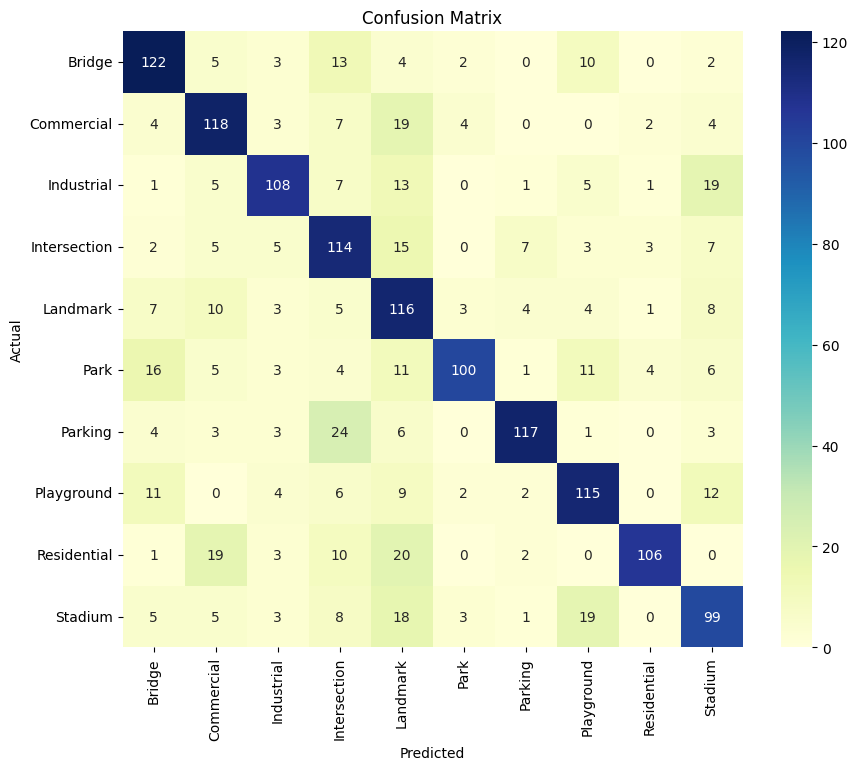

In [ ]:
model_vit = models.vit_b_16(pretrained=False)

model_vit.heads.head = nn.Linear(
    model_vit.heads.head.in_features,
    num_classes
)

model_vit = model_vit.to(device)

criterion_vit = nn.CrossEntropyLoss()
optimizer_vit = optim.Adam(model_vit.parameters(), lr=0.0001)

trainer = ModelTrainer(model_vit,train_loader,val_loader,test_loader,criterion_vit,optimizer_vit,device)

trainer.train(num_epochs=15)
trainer.evaluate()

**Optimized Vision Transformer (ViT)**

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ViT_B_16_Weights.IMAGENET1K_V1`. You can also use `weights=ViT_B_16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 166MB/s]


Epoch [1/15] | Train Loss: 0.4538, Train Acc: 0.8538 | Val Loss: 0.1953, Val Acc: 0.9400
Epoch [2/15] | Train Loss: 0.1676, Train Acc: 0.9467 | Val Loss: 0.2130, Val Acc: 0.9350
Epoch [3/15] | Train Loss: 0.1223, Train Acc: 0.9588 | Val Loss: 0.1688, Val Acc: 0.9400
Epoch [4/15] | Train Loss: 0.0843, Train Acc: 0.9690 | Val Loss: 0.1435, Val Acc: 0.9613
Epoch [5/15] | Train Loss: 0.1071, Train Acc: 0.9651 | Val Loss: 0.2159, Val Acc: 0.9313
Epoch [6/15] | Train Loss: 0.0668, Train Acc: 0.9782 | Val Loss: 0.2498, Val Acc: 0.9337
Epoch [7/15] | Train Loss: 0.0609, Train Acc: 0.9800 | Val Loss: 0.1615, Val Acc: 0.9475
Epoch [8/15] | Train Loss: 0.0609, Train Acc: 0.9771 | Val Loss: 0.1627, Val Acc: 0.9563
Epoch [9/15] | Train Loss: 0.0755, Train Acc: 0.9767 | Val Loss: 0.1744, Val Acc: 0.9463
Epoch [10/15] | Train Loss: 0.0565, Train Acc: 0.9809 | Val Loss: 0.2709, Val Acc: 0.9263
Epoch [11/15] | Train Loss: 0.0490, Train Acc: 0.9832 | Val Loss: 0.2371, Val Acc: 0.9225
Epoch [12/15] | Tra

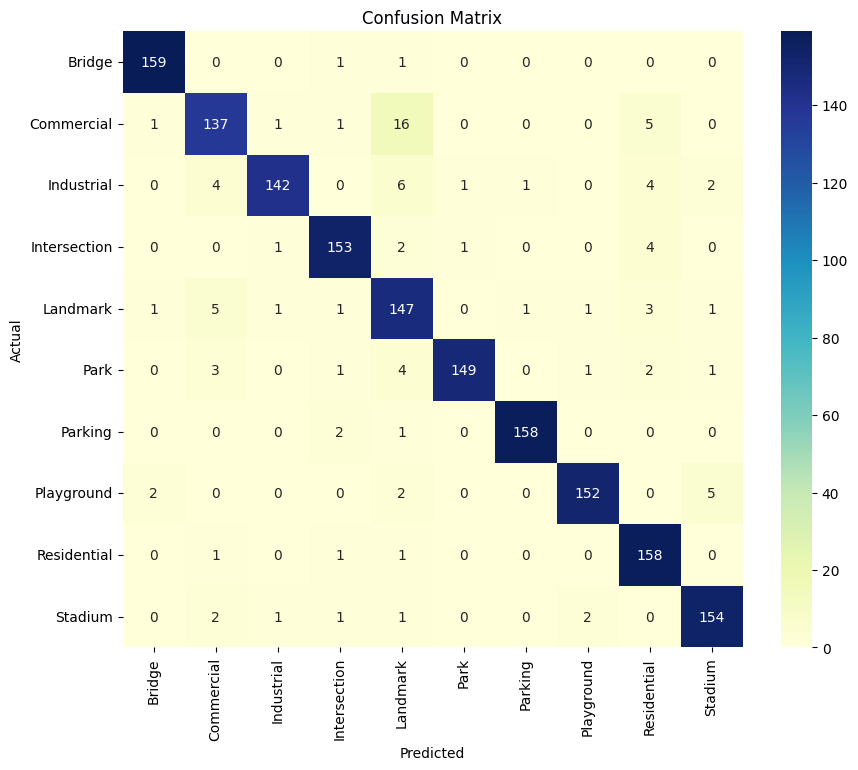

In [ ]:
model_vit = models.vit_b_16(pretrained=True)

model_vit.heads.head = nn.Linear(
    model_vit.heads.head.in_features,
    num_classes
)

model_vit = model_vit.to(device)

criterion_vit = nn.CrossEntropyLoss()
optimizer_vit = optim.Adam(model_vit.parameters(), lr=0.0001)

trainer = ModelTrainer(model_vit,train_loader,val_loader,test_loader,criterion_vit,optimizer_vit,device)

trainer.train(num_epochs=15)
trainer.evaluate()

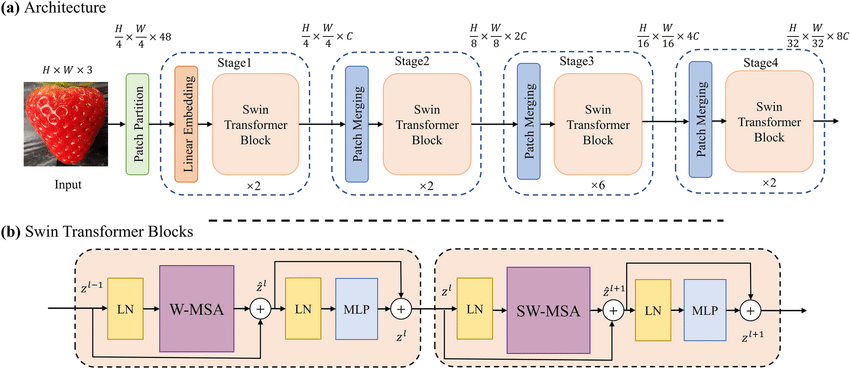

**Swin Transformer**

The Swin Transformer is a hierarchical vision transformer architecture specifically designed to overcome the computational limitations of standard Vision Transformers when processing high-resolution images. Instead of applying self-attention globally across all image patches, Swin Transformer computes attention within local windows and gradually merges information across larger image regions. As illustrated in the architecture, the input image is first divided into non-overlapping patches through a patch partition operation. These patches are then embedded into feature vectors and processed through multiple hierarchical stages. Each stage consists of several Swin Transformer Blocks, which contain Layer Normalization, Multi-Layer Perceptrons, and two forms of self-attention: Window-based Multi-Head Self-Attention (W-MSA) and Shifted Window Multi-Head Self-Attention (SW-MSA). The shifted window mechanism enables information exchange between neighboring windows, allowing the model to capture both local and global contextual relationships while maintaining computational efficiency. Between stages, Patch Merging layers reduce the spatial dimensions of the feature maps while increasing the feature depth, creating a hierarchical representation similar to that found in convolutional neural networks. As the data progresses through the four stages, the network learns increasingly abstract visual features, ranging from low-level textures to high-level semantic structures. Finally, the extracted features are aggregated and passed through a classification head that produces the final predictions. A Softmax activation function converts these outputs into probabilities corresponding to the ten urban scene categories, enabling accurate scene recognition based on both local details and global image context.


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Epoch [1/15] | Train Loss: 2.1331, Train Acc: 0.2335 | Val Loss: 1.8175, Val Acc: 0.3375
Epoch [2/15] | Train Loss: 1.7629, Train Acc: 0.3704 | Val Loss: 1.5420, Val Acc: 0.4650
Epoch [3/15] | Train Loss: 1.4125, Train Acc: 0.4901 | Val Loss: 1.1675, Val Acc: 0.5725
Epoch [4/15] | Train Loss: 1.1544, Train Acc: 0.5946 | Val Loss: 0.9628, Val Acc: 0.6787
Epoch [5/15] | Train Loss: 1.0026, Train Acc: 0.6581 | Val Loss: 0.8292, Val Acc: 0.7075
Epoch [6/15] | Train Loss: 0.8942, Train Acc: 0.6976 | Val Loss: 0.7391, Val Acc: 0.7312
Epoch [7/15] | Train Loss: 0.8151, Train Acc: 0.7155 | Val Loss: 0.7485, Val Acc: 0.7400
Epoch [8/15] | Train Loss: 0.7481, Train Acc: 0.7357 | Val Loss: 0.7981, Val Acc: 0.7262
Epoch [9/15] | Train Loss: 0.6912, Train Acc: 0.7579 | Val Loss: 0.6910, Val Acc: 0.7662
Epoch [10/15] | Train Loss: 0.6546, Train Acc: 0.7755 | Val Loss: 0.6652, Val Acc: 0.7638
Epoch [11/15] | Train Loss: 0.6118, Train Acc: 0.7907 | Val Loss: 0.7095, Val Acc: 0.7488
Epoch [12/15] | Tra

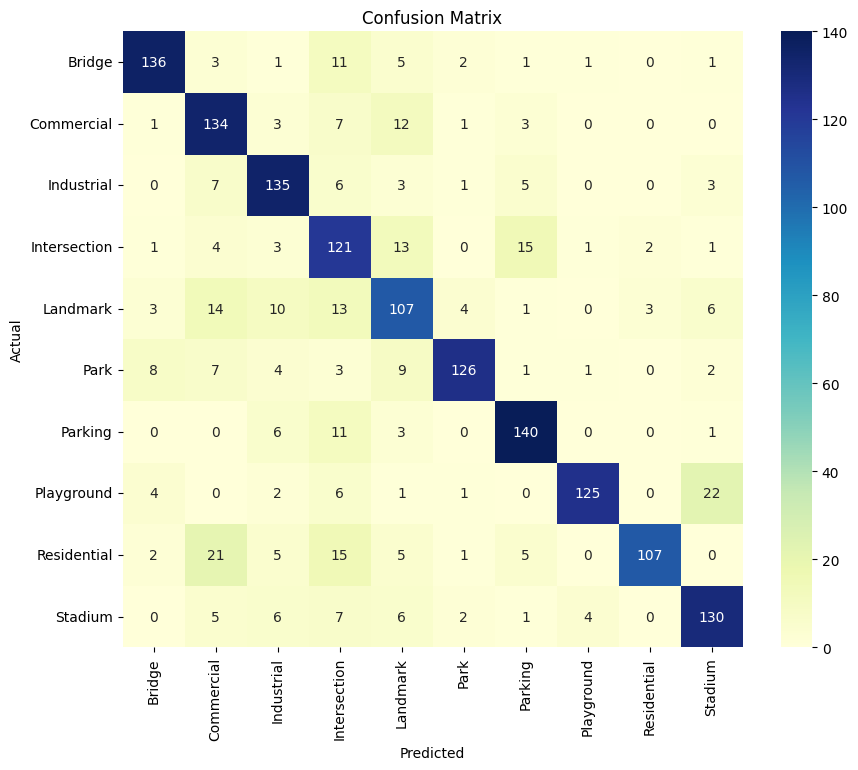

In [ ]:
model_swin = models.swin_t(pretrained=False)

model_swin.head = nn.Linear(
    model_swin.head.in_features,
    num_classes
)

model_swin = model_swin.to(device)

criterion_swin = nn.CrossEntropyLoss()
optimizer_swin = optim.Adam(model_swin.parameters(), lr=0.0001)

trainer = ModelTrainer(model_swin,train_loader,val_loader,test_loader,criterion_swin,optimizer_swin,device)

trainer.train(num_epochs=15)
trainer.evaluate()

**Optimized Swin Transformer**

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Swin_T_Weights.IMAGENET1K_V1`. You can also use `weights=Swin_T_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:00<00:00, 175MB/s]


Epoch [1/15] | Train Loss: 0.4735, Train Acc: 0.8454 | Val Loss: 0.0969, Val Acc: 0.9650
Epoch [2/15] | Train Loss: 0.1736, Train Acc: 0.9458 | Val Loss: 0.0775, Val Acc: 0.9738
Epoch [3/15] | Train Loss: 0.1199, Train Acc: 0.9606 | Val Loss: 0.0961, Val Acc: 0.9688
Epoch [4/15] | Train Loss: 0.0783, Train Acc: 0.9742 | Val Loss: 0.0833, Val Acc: 0.9725
Epoch [5/15] | Train Loss: 0.0746, Train Acc: 0.9766 | Val Loss: 0.0959, Val Acc: 0.9637
Epoch [6/15] | Train Loss: 0.0499, Train Acc: 0.9825 | Val Loss: 0.1329, Val Acc: 0.9600
Epoch [7/15] | Train Loss: 0.0613, Train Acc: 0.9785 | Val Loss: 0.1145, Val Acc: 0.9700
Epoch [8/15] | Train Loss: 0.0487, Train Acc: 0.9851 | Val Loss: 0.0902, Val Acc: 0.9775
Epoch [9/15] | Train Loss: 0.0490, Train Acc: 0.9843 | Val Loss: 0.1077, Val Acc: 0.9637
Epoch [10/15] | Train Loss: 0.0566, Train Acc: 0.9809 | Val Loss: 0.0771, Val Acc: 0.9825
Epoch [11/15] | Train Loss: 0.0561, Train Acc: 0.9832 | Val Loss: 0.1776, Val Acc: 0.9500
Epoch [12/15] | Tra

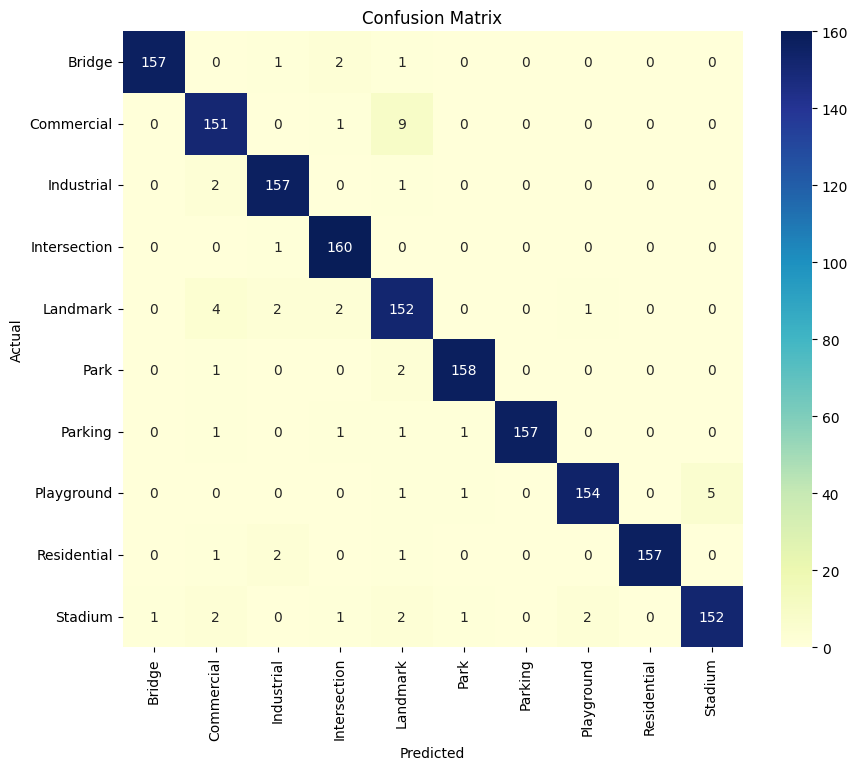

In [8]:
model_swin = models.swin_t(pretrained=True)

model_swin.head = nn.Linear(
    model_swin.head.in_features,
    num_classes
)

model_swin = model_swin.to(device)

criterion_swin = nn.CrossEntropyLoss()
optimizer_swin = optim.Adam(model_swin.parameters(), lr=0.0001)

trainer = ModelTrainer(model_swin,train_loader,val_loader,test_loader,criterion_swin,optimizer_swin,device)

trainer.train(num_epochs=15)
trainer.evaluate()

**Comparison of all architectures used for pretrained = False**

The Swin Transformer achieved the best overall performance with an accuracy of 78.37%, followed by ResNet101 (75.20%), VGG19 (74.95%), EfficientNet-B0 (74.21%), and Vision Transformer (69.30%). The relatively similar performance of VGG19, ResNet101, and EfficientNet-B0 suggests that all three convolutional architectures are capable of learning meaningful representations of the urban scenes despite starting with randomly initialized weights. Among the transformer-based models, the Swin Transformer significantly outperformed the standard Vision Transformer, demonstrating the advantage of its hierarchical architecture and shifted-window attention mechanism, which allows it to capture both local and global image information more effectively. In contrast, the Vision Transformer produced the lowest accuracy and the highest error metrics, indicating that transformer architectures generally require larger datasets to learn effective visual representations when trained from scratch. Overall, the results show that while all models were able to learn the classification task, architectures that incorporate stronger inductive biases toward image structure, such as convolutional networks and the hierarchical Swin Transformer, are more effective when limited training data is available.


**Comparison of all architectures used for pretrained = True**

All architectures experienced substantial improvements in performance, highlighting the effectiveness of transfer learning. EfficientNet-B0 achieved the highest accuracy of 97.02%, closely followed by the Swin Transformer with 96.64%, ResNet101 with 95.71%, VGG19 with 94.59%, and the Vision Transformer with 93.78%. The pretrained models also exhibited very high precision, recall, F1-scores, and Kappa coefficients while maintaining extremely low error metrics. These results demonstrate that the features learned from large-scale datasets such as ImageNet can be successfully transferred to urban scene classification, enabling the models to converge faster and generalize more effectively. EfficientNet-B0 achieved the best overall classification accuracy, likely due to its compound scaling strategy that balances network depth, width, and image resolution, allowing it to extract highly discriminative features while remaining computationally efficient. Similarly, the pretrained Swin Transformer performed exceptionally well, benefiting from its ability to model both local details and broader contextual relationships within images.


**Conclusion**

Considering all models together, transfer learning proved to be the most influential factor affecting performance. Every architecture achieved a significant increase in accuracy when pretrained weights were used, with gains ranging from approximately 16% to 25%. Although transformer-based models have achieved state-of-the-art results on many large-scale computer vision benchmarks, they did not surpass EfficientNet-B0 in this study. This can be explained by the size and nature of the dataset. Transformer architectures typically require very large amounts of training data because they rely heavily on learning relationships between image patches rather than exploiting the strong spatial inductive biases naturally present in convolutional neural networks. CNNs inherently assume that nearby pixels are related and can therefore learn useful visual patterns more efficiently from smaller datasets. Even though transfer learning significantly improved both ViT and Swin Transformer, the dataset size was likely not large enough for the transformers to fully exploit their advantages. Furthermore, urban scene classification often depends on local textures, edges, and structural patterns that convolutional architectures such as EfficientNet and ResNet are particularly effective at capturing. Overall, EfficientNet-B0 with pretrained weights emerged as the best-performing model, while the Swin Transformer demonstrated that modern transformer architectures can achieve highly competitive results when supported by transfer learning.
